# Actividad 8 – Trasladar y rotar

**Objetivo**: usar warpAffine.

En esta actividad vamos a:
1. Cargar una imagen
2. Trasladarla 50 píxeles a la derecha y 30 abajo
3. Rotarla 30 grados
4. Mostrar las tres versiones

## 1. Importar librerías necesarias

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Configurar matplotlib para mostrar imágenes en el notebook
%matplotlib inline

## 2. Cargar imagen

Cambia la ruta por la ubicación de tu imagen.

✓ Imagen cargada correctamente
  Dimensiones: 500 x 333 píxeles


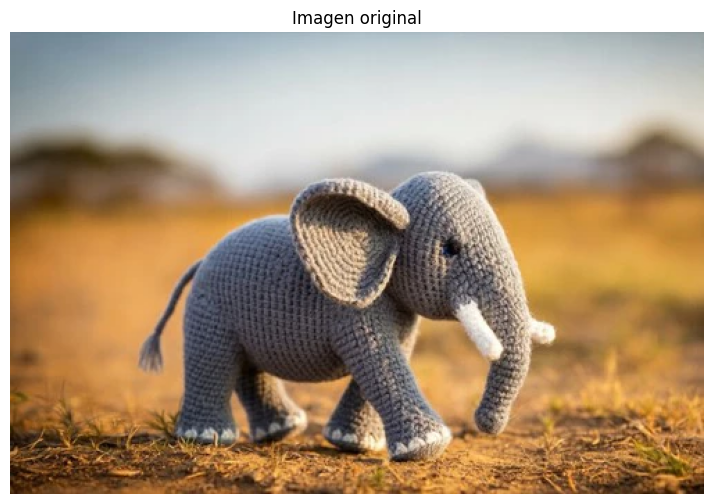

In [2]:
# Cargar la imagen
imagen = cv2.imread('imagen.webp')

# Verificar que la imagen se cargó correctamente
if imagen is None:
    print("Error: No se pudo cargar la imagen. Verifica la ruta del archivo.")
else:
    print("✓ Imagen cargada correctamente")
    
    # Obtener dimensiones
    alto, ancho = imagen.shape[:2]
    print(f"  Dimensiones: {ancho} x {alto} píxeles")
    
    # Mostrar la imagen original
    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(imagen_rgb)
    plt.axis('off')
    plt.title('Imagen original')
    plt.show()

## 3. Trasladar imagen

Usamos `cv2.warpAffine()` con una matriz de traslación para mover la imagen.

In [3]:
# Definir el desplazamiento
desplazamiento_x = 50  # píxeles a la derecha
desplazamiento_y = 30  # píxeles hacia abajo

# Crear matriz de traslación
# La matriz es: [[1, 0, tx], [0, 1, ty]]
matriz_traslacion = np.float32([[1, 0, desplazamiento_x], 
                                 [0, 1, desplazamiento_y]])

# Aplicar la transformación afín
imagen_trasladada = cv2.warpAffine(imagen, matriz_traslacion, (ancho, alto))

print(f"✓ Imagen trasladada")
print(f"  Desplazamiento X: +{desplazamiento_x} px (derecha)")
print(f"  Desplazamiento Y: +{desplazamiento_y} px (abajo)")
print(f"  Matriz de traslación:")
print(f"  {matriz_traslacion}")

✓ Imagen trasladada
  Desplazamiento X: +50 px (derecha)
  Desplazamiento Y: +30 px (abajo)
  Matriz de traslación:
  [[ 1.  0. 50.]
 [ 0.  1. 30.]]


## 4. Rotar imagen

Usamos `cv2.getRotationMatrix2D()` para obtener la matriz de rotación.

In [4]:
# Definir parámetros de rotación
centro = (ancho // 2, alto // 2)  # Centro de la imagen
angulo = 30  # Grados (positivo = sentido antihorario)
escala = 1.0  # Sin cambio de escala

# Obtener matriz de rotación
matriz_rotacion = cv2.getRotationMatrix2D(centro, angulo, escala)

# Aplicar la transformación afín
imagen_rotada = cv2.warpAffine(imagen, matriz_rotacion, (ancho, alto))

print(f"✓ Imagen rotada")
print(f"  Centro de rotación: {centro}")
print(f"  Ángulo: {angulo}° (antihorario)")
print(f"  Escala: {escala}")
print(f"  Matriz de rotación:")
print(f"  {matriz_rotacion}")

✓ Imagen rotada
  Centro de rotación: (250, 166)
  Ángulo: 30° (antihorario)
  Escala: 1.0
  Matriz de rotación:
  [[  0.8660254    0.5        -49.50635095]
 [ -0.5          0.8660254  147.23978297]]


## 5. Mostrar las tres versiones

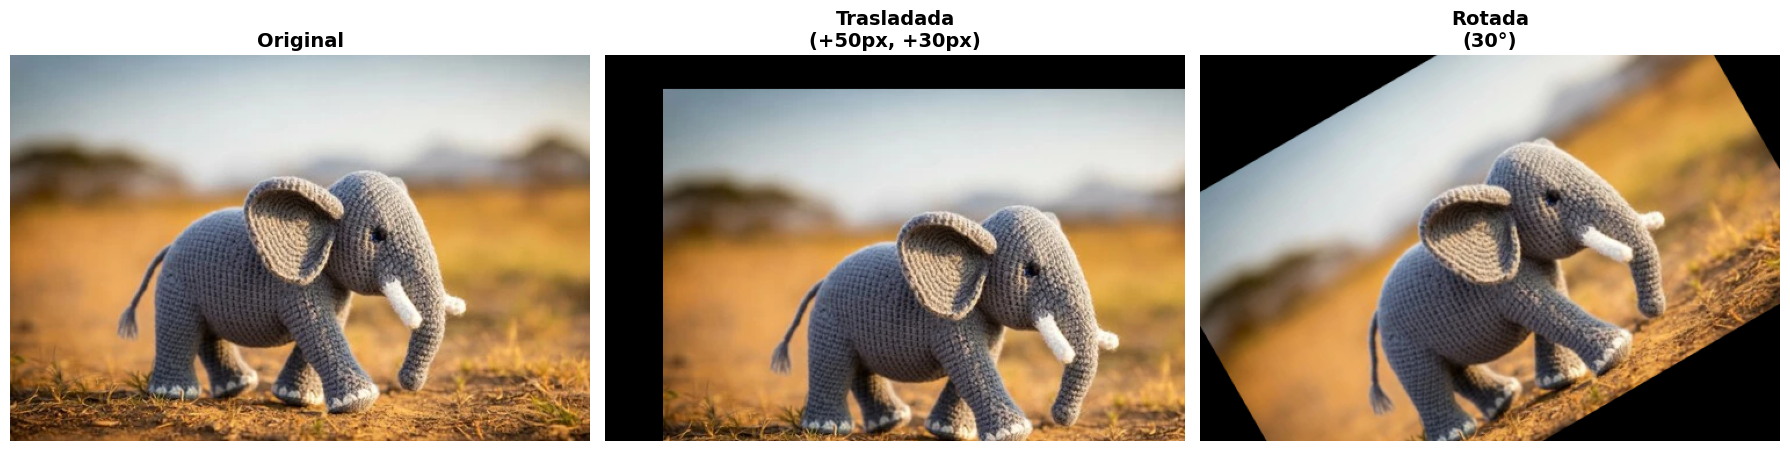

In [5]:
# Convertir todas las imágenes de BGR a RGB para matplotlib
imagen_trasladada_rgb = cv2.cvtColor(imagen_trasladada, cv2.COLOR_BGR2RGB)
imagen_rotada_rgb = cv2.cvtColor(imagen_rotada, cv2.COLOR_BGR2RGB)

# Mostrar las tres versiones
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original
axes[0].imshow(imagen_rgb)
axes[0].set_title('Original', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Trasladada
axes[1].imshow(imagen_trasladada_rgb)
axes[1].set_title(f'Trasladada\n(+{desplazamiento_x}px, +{desplazamiento_y}px)', 
                  fontsize=14, fontweight='bold')
axes[1].axis('off')

# Rotada
axes[2].imshow(imagen_rotada_rgb)
axes[2].set_title(f'Rotada\n({angulo}°)', fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()